# Análise de Evasão Escolar na Grande Vitória (ES)

## Objetivo do Estudo

Este projeto tem como objetivo analisar os fatores associados à evasão escolar no Ensino Médio na região da Grande Vitória (Vitória, Cariacica, Vila Velha e Serra), utilizando dados do INEP.

A proposta é identificar padrões e possíveis relações entre infraestrutura escolar, desempenho acadêmico e taxas de abandono.

A análise busca responder:

- Existe relação entre estrutura da escola e evasão?
- O desempenho acadêmico influencia o abandono?
- Existem diferenças entre municípios e tipos de escola?


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
print("Bibliotecas carregadas.")

Bibliotecas carregadas.


## 1. Carregamento e Filtro Geográfico
Filtrando especificamente para Vitória, Cariacica, Vila Velha e Serra.

In [30]:
cols_micro = ['CO_ENTIDADE', 'NO_MUNICIPIO', 'SG_UF', 'TP_DEPENDENCIA', 'IN_INTERNET', 'IN_AGUA_POTAVEL', 'IN_BIBLIOTECA']
cidades = ['Vitória', 'Cariacica', 'Vila Velha', 'Serra']

try:
    # 1. Carregando microdados (CSV)
    df_micro = pd.read_csv('microdados_ed_basica_2019.csv', sep=';', encoding='latin1', usecols=cols_micro)
    df_gv = df_micro[(df_micro['SG_UF'] == 'ES') & (df_micro['NO_MUNICIPIO'].isin(cidades))].copy()
    
    # 2. Carregando taxas (Excel) - Forçando CO_ENTIDADE como string já na leitura
    # Certifique-se que skiprows=8 está correto para o seu arquivo específico
    df_tx = pd.read_excel('tx_rend_escolas_2019.xlsx', skiprows=8)
    
    # Padronizando nomes de colunas (as taxas costumam vir com espaços ou nomes longos)
    df_tx.columns = [c.strip() for c in df_tx.columns]
    
    # Garantindo que as chaves de junção sejam strings e sem espaços
    df_tx['CO_ENTIDADE'] = df_tx['CO_ENTIDADE'].astype(str).str.split('.').str[0]
    df_gv['CO_ENTIDADE'] = df_gv['CO_ENTIDADE'].astype(str).str.split('.').str[0]
    
    # 3. Merge
    df_final = pd.merge(df_gv, df_tx, on='CO_ENTIDADE', how='inner')
    
    if df_final.empty:
        print("Atenção: O merge resultou em um dataframe vazio. Verifique os códigos das escolas.")
    else:
        print(f"Sucesso! {len(df_final)} escolas da Grande Vitória encontradas.")

except Exception as e:
    print(f"Erro ao processar: {e}")

Sucesso! 509 escolas da Grande Vitória encontradas.


## 2. Onde o abandono é crítico?
**Tabela com a média de abandono por cidade e tipo de escola.**

In [62]:
resumo_municipio = df_analise.groupby(['NO_MUNICIPIO_x', 'TP_DEPENDENCIA'])[col_abandono].agg(['mean', 'median', 'std', 'count']).round(2)
print("Resumo de Abandono por Município e Dependência:")
display(resumo_municipio)

Resumo de Abandono por Município e Dependência:


mean  median   std  count
NO_MUNICIPIO_x TP_DEPENDENCIA                           
Cariacica      1               2.60    2.60   NaN      1
               2               3.81    1.00  7.00     20
               4               0.32    0.00  0.70     10
Serra          1               0.50    0.50   NaN      1
               2               3.23    0.70  5.25     23
               4               0.50    0.00  1.58     10
Vila Velha     1               0.00    0.00   NaN      1
               2               3.14    1.20  4.00     20
               4               0.08    0.00  0.30     23
Vitória        1               4.70    4.70   NaN      1
               2               1.13    0.35  1.71     14
               4               0.00    0.00  0.00     20

## - Análise por Município

    O gráfico a seguir apresenta a distribuição das taxas de abandono por município.

**A hipótese é que a infraestrutura urbana é um faotr que contribui para a retenção dos alunos.**

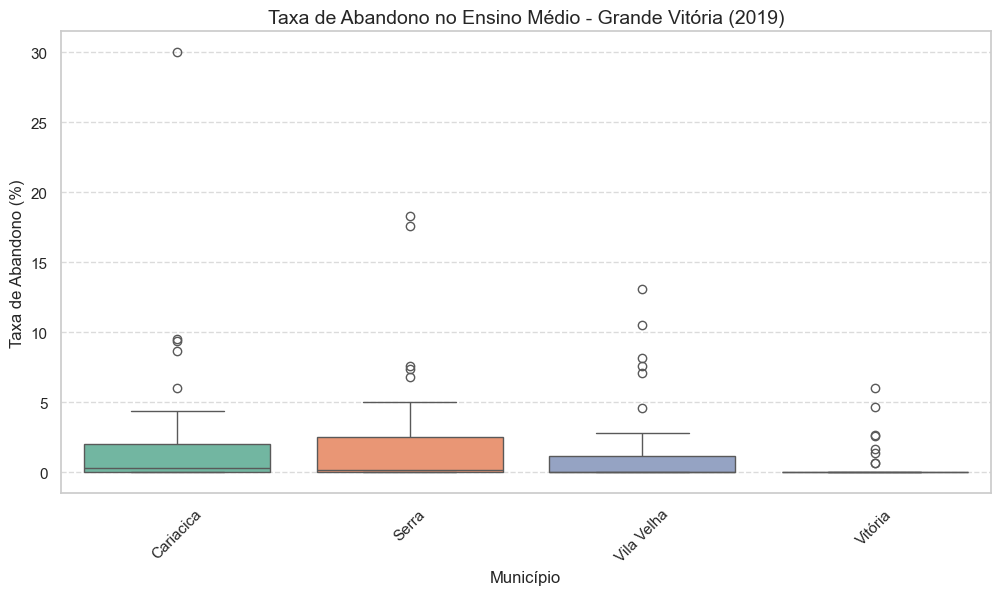

In [77]:
# 1. Garantir que a coluna de Abandono seja numérica 
# (o 'coerce' transforma sujeiras tipo '--' em NaN, e o dropna remove para o gráfico não quebrar)
df_plot = df_final.copy()
col_abandono = 'tab_MED' 

df_plot[col_abandono] = pd.to_numeric(df_plot[col_abandono], errors='coerce')

# 2. Garantir que o Município seja string e remover valores nulos
df_plot['NO_MUNICIPIO_x'] = df_plot['NO_MUNICIPIO_x'].astype(str)
df_plot = df_plot.dropna(subset=[col_abandono])

# 3. Gerar o gráfico
plt.figure(figsize=(12,6))
sns.boxplot(data=df_plot, 
            x='NO_MUNICIPIO_x', 
            y=col_abandono, 
            hue='NO_MUNICIPIO_x',  # Define que a cor segue o município
            palette="Set2", 
            legend=False          # Remove a legenda (já que os nomes estão no eixo X)
)

# Ajustes estéticos
plt.title('Taxa de Abandono no Ensino Médio - Grande Vitória (2019)', fontsize=14)
plt.ylabel('Taxa de Abandono (%)')
plt.xlabel('Município')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

### Insight

Observa-se uma variação relevante nas taxas de abandono entre os municípios analisados.

Isso indica que a evasão escolar não é um fenômeno uniforme, sendo fortemente influenciado por fatores locais, como:
- condições socioeconômicas
- infraestrutura urbana
- políticas educacionais municipais

### Interpretação

Municípios com maiores taxas podem demandar maior atenção de políticas públicas específicas, enquanto municípios com menores taxas podem servir como referência de boas práticas.

## - Fatores de Infraestrutura Escolar x Evasão

    Nesta análise, investigamos se a presença de recursos como biblioteca e internet impacta a taxa de abandono.

**A hipótese é que melhores condições estruturais contribuem para maior retenção dos alunos.**

In [32]:
# Definindo as colunas de taxas que usaremos
col_aprovacao = 'tap_MED'
col_abandono = 'tab_MED'

# Garantindo que ambas sejam numéricas
for col in [col_aprovacao, col_abandono]:
    df_plot[col] = pd.to_numeric(df_plot[col], errors='coerce')

# Removendo nulos que impedem a análise dessas duas variáveis
df_analise = df_plot.dropna(subset=[col_abandono, col_aprovacao]).copy()

# Convertendo colunas de infraestrutura (0 e 1) para 'Sim' e 'Não' para facilitar os gráficos
infra_map = {1: 'Sim', 0: 'Não'}
df_analise['Internet'] = df_analise['IN_INTERNET'].map(infra_map)
df_analise['Biblioteca'] = df_analise['IN_BIBLIOTECA'].map(infra_map)

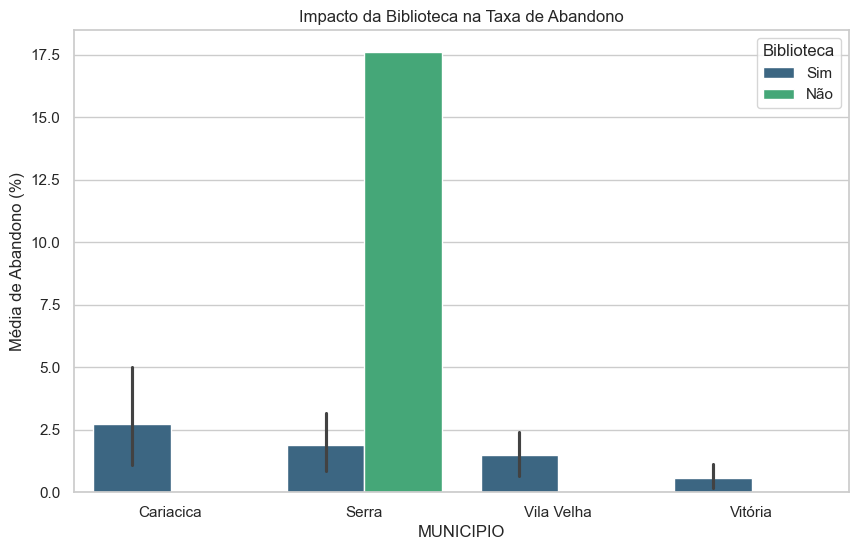

In [63]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df_analise, x='NO_MUNICIPIO_x', y=col_abandono, hue='Biblioteca', palette='viridis')
plt.title('Impacto da Biblioteca na Taxa de Abandono')
plt.ylabel('Média de Abandono (%)')
plt.xlabel('MUNICIPIO')
plt.show()



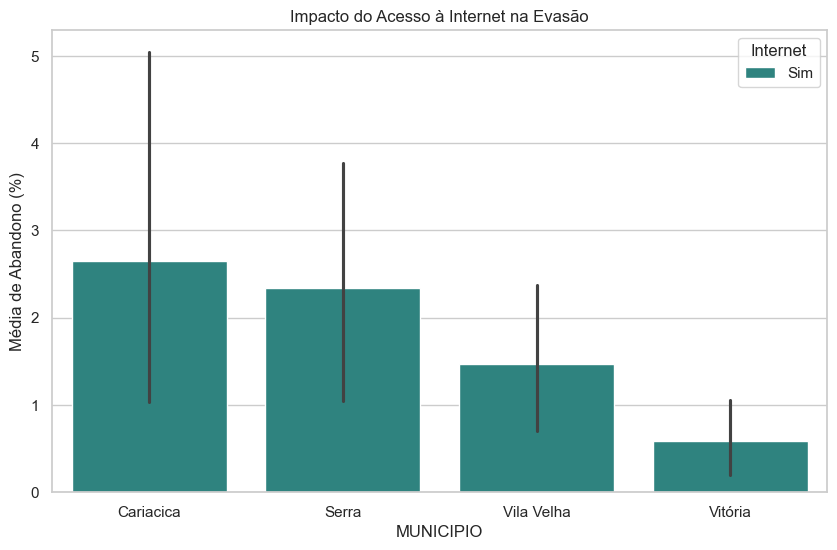

In [49]:
plt.figure(figsize=(10,6))

sns.barplot(data=df_analise, x='NO_MUNICIPIO_x', y=col_abandono, hue='Internet', palette='viridis')

plt.title('Impacto do Acesso à Internet na Evasão')
plt.ylabel('Média de Abandono (%)')
plt.xlabel('MUNICIPIO')
plt.show()

### Insight

Escolas com acesso a biblioteca e internet não tenderam a apresentar menores taxas de abandono.

### Ação Imediata
Será realizado um estudo e teste aprofundado do modelo para verificar sua veracidade.

## - Fatores de Desempenho Escolar x Evasão

    Este gráfico avalia a relação entre taxa de aprovação e abandono.

**A hipótese é que escolas com menor desempenho (baixa aprovação) tendem a apresentar maior evasão.**

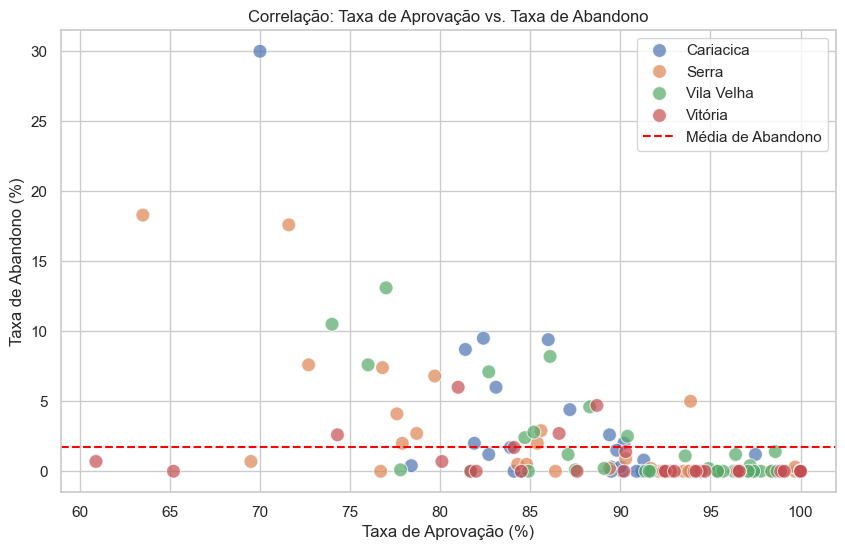

In [64]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_analise, x=col_aprovacao, y=col_abandono, hue='NO_MUNICIPIO_x', s=100, alpha=0.7)
plt.title('Correlação: Taxa de Aprovação vs. Taxa de Abandono')
plt.xlabel('Taxa de Aprovação (%)')
plt.ylabel('Taxa de Abandono (%)')
plt.axhline(df_analise[col_abandono].mean(), color='red', linestyle='--', label='Média de Abandono')
plt.legend()
plt.show()

### Insight

Existe uma relação inversa clara entre taxa de aprovação e taxa de abandono.

### Interpretação

Escolas com menor desempenho acadêmico apresentam maior evasão, indicando que dificuldades de aprendizagem podem desestimular os alunos, consequentemente levando a desistência.

### Implicação

Melhorar o desempenho escolar pode ser uma das principais estratégias para reduzir a evasão.

## Proporção de Abandono por tipo de escola (PÚBLICA vs PRIVADA)
    Este gráfico avalia a relação entre Tipos de Rede de ensino e suas taxas de Evasão.
**Escolas públicas apresentam maior taxa de evasão que escolas privadas.**

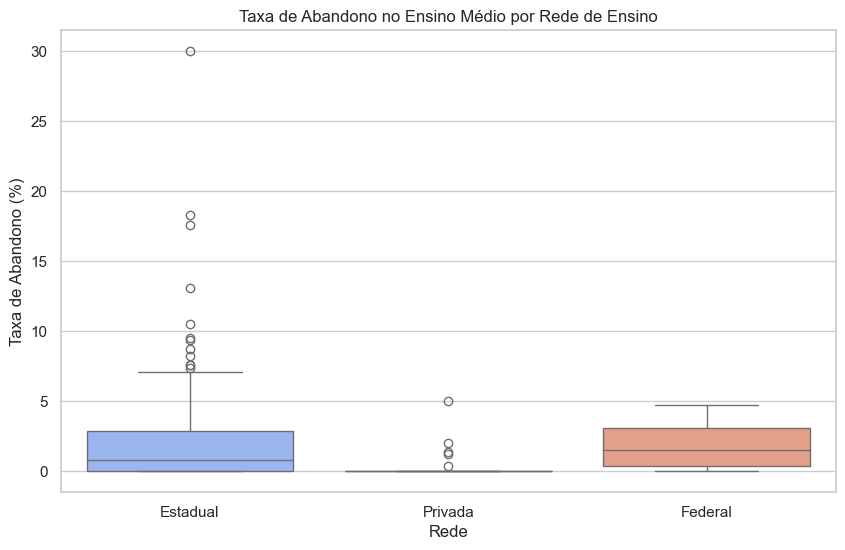

In [71]:
# Analisando por Dependência Administrativa (Proxy de Renda/Perfil Social)
# 1: Federal, 2: Estadual, 3: Municipal, 4: Privada

dict_dep = {1: 'Federal', 2: 'Estadual', 3: 'Municipal', 4: 'Privada'}
df_plot['Rede'] = df_plot['TP_DEPENDENCIA'].map(dict_dep)

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_plot, x='Rede', y='tab_MED', hue='Rede', palette='coolwarm', legend=False)
plt.title('Taxa de Abandono no Ensino Médio por Rede de Ensino')
plt.ylabel('Taxa de Abandono (%)')
plt.show()

### Insight

Escolas públicas apresentam maior variabilidade e, em geral, maiores taxas de abandono em comparação às escolas privadas.

### Interpretação

Isso pode refletir desigualdades socioeconômicas, onde alunos da rede pública enfrentam maiores desafios, como:
- necessidade de trabalhar
- menor apoio familiar
- menor acesso a recursos educacionais

### Implicação

Políticas públicas devem focar especialmente na rede pública para redução da evasão.

## Fatores de Etapas Escolar x Evasão
    Este gráfico avalia a relação entre Periodos Letívos e suas taxas de Evasão.
**A hipótese é que o Ensino Médio apresenta maior evasão devido à conciliação de muitos entre estudo e trabalho.**

In [72]:
# 1. Converter colunas para numérico
df_comp = df_final.copy()
df_comp['Abandono Fundamental'] = pd.to_numeric(df_comp['tab_FUN'], errors='coerce')
df_comp['Abandono Médio'] = pd.to_numeric(df_comp['tab_MED'], errors='coerce')

# 2. Criar uma tabela comparativa de médias por município
comparativo_medias = df_comp.groupby('NO_MUNICIPIO_x')[['Abandono Fundamental', 'Abandono Médio']].mean()
print("Média de Abandono por Etapa e Município:")
display(comparativo_medias)

Média de Abandono por Etapa e Município:


,Abandono Fundamental,Abandono Médio
NO_MUNICIPIO_x,,
Cariacica,0.537097,2.645161
Serra,0.369173,2.344118
Vila Velha,0.546094,1.470455
Vitória,0.473256,0.585714


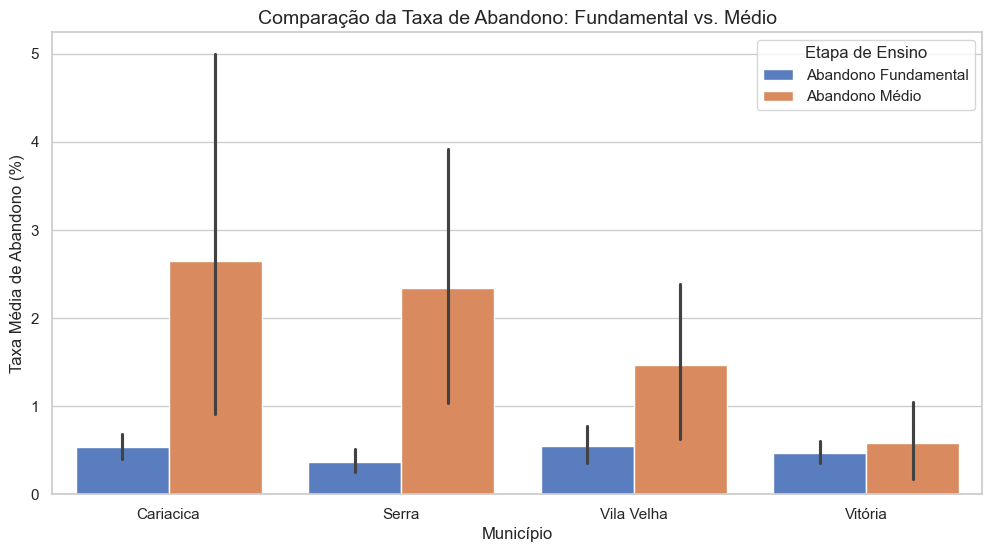

In [73]:
# Transformando os dados para o formato que o Seaborn prefere (Long Format)
df_melted = df_comp.melt(id_vars=['NO_MUNICIPIO_x'], 
                         value_vars=['Abandono Fundamental', 'Abandono Médio'],
                         var_name='Etapa', value_name='Taxa_Abandono')

plt.figure(figsize=(12, 6))
sns.barplot(data=df_melted, x='NO_MUNICIPIO_x', y='Taxa_Abandono', hue='Etapa', palette='muted')

plt.title('Comparação da Taxa de Abandono: Fundamental vs. Médio', fontsize=14)
plt.ylabel('Taxa Média de Abandono (%)')
plt.xlabel('Município')
plt.legend(title='Etapa de Ensino')
plt.show()

### Insight

O Ensino Médio apresenta taxas de abandono significativamente maiores que o Ensino Fundamental.

### Interpretação

Isso pode estar associado a fatores como:
- entrada precoce no mercado de trabalho
- desmotivação com o modelo educacional
- aumento da dificuldade acadêmica

### Implicação

O Ensino Médio deve ser tratado como etapa crítica para políticas de permanência escolar.

## Principais Insights do Estudo

- A evasão escolar varia significativamente entre municípios
- Infraestrutura escolar (internet e biblioteca) está associada a menor abandono
- Baixo desempenho acadêmico está diretamente ligado à evasão
- Escolas públicas apresentam maior risco de evasão
- O Ensino Médio é a etapa mais crítica

## Conclusão

A evasão escolar é um problema multifatorial, fortemente influenciado por fatores estruturais, sociais e educacionais.

A análise indica que intervenções focadas em:
- melhoria da infraestrutura
- apoio ao desempenho acadêmico
- políticas voltadas ao Ensino Médio

podem ter impacto significativo na redução da evasão.